# Head Pose Estimation with UniFace

This notebook demonstrates head pose estimation using the **UniFace** library.

## 1. Install UniFace

In [1]:
%pip install -q uniface

# Clone repo for assets (Colab only)
import os
if 'COLAB_GPU' in os.environ or 'COLAB_RELEASE_TAG' in os.environ:
    if not os.path.exists('uniface'):
        !git clone --depth 1 https://github.com/yakhyo/uniface.git
    os.chdir('uniface/examples')

Note: you may need to restart the kernel to use updated packages.


## 2. Import Libraries

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

import uniface
from uniface.detection import RetinaFace
from uniface.headpose import HeadPose
from uniface.draw import draw_head_pose

print(f"UniFace version: {uniface.__version__}")

UniFace version: 3.3.0


## 3. Initialize Models

In [3]:
# Initialize face detector
detector = RetinaFace(confidence_threshold=0.5)

# Initialize head pose estimator (default: ResNet18 backbone)
head_pose = HeadPose()

print("Models initialized successfully!")

Models initialized successfully!


## 4. Process All Test Images

Display original images in the first row and head-pose-annotated images in the second row.

In [4]:
# Get all test images
test_images_dir = Path('../assets/test_images')
test_images = sorted(test_images_dir.glob('*.jpg'))

original_images = []
annotated_images = []

for img_path in test_images:
    image = cv2.imread(str(img_path))
    if image is None:
        continue

    # Store original (BGR -> RGB for display)
    original_images.append(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

    # Detect faces and estimate head pose
    faces = detector.detect(image)

    for face in faces:
        x1, y1, x2, y2 = map(int, face.bbox)
        face_crop = image[y1:y2, x1:x2]

        if face_crop.size == 0:
            continue

        result = head_pose.estimate(face_crop)
        draw_head_pose(image, face.bbox, result.pitch, result.yaw, result.roll)

        print(f"{img_path.name}: pitch={result.pitch:.1f}°, yaw={result.yaw:.1f}°, roll={result.roll:.1f}°")

    annotated_images.append(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

print(f"\nProcessed {len(original_images)} images")

image0.jpg: pitch=-23.1°, yaw=-4.2°, roll=-27.6°
image1.jpg: pitch=-14.7°, yaw=18.0°, roll=-17.2°
image2.jpg: pitch=-3.7°, yaw=1.7°, roll=19.5°
image3.jpg: pitch=-3.3°, yaw=-15.6°, roll=-26.8°
image4.jpg: pitch=8.0°, yaw=-13.9°, roll=-18.3°
image5.jpg: pitch=-4.8°, yaw=33.7°, roll=7.8°

Processed 6 images


## 5. Visualize Results

**First row**: Original images  
**Second row**: Images with head pose 3D cube overlay

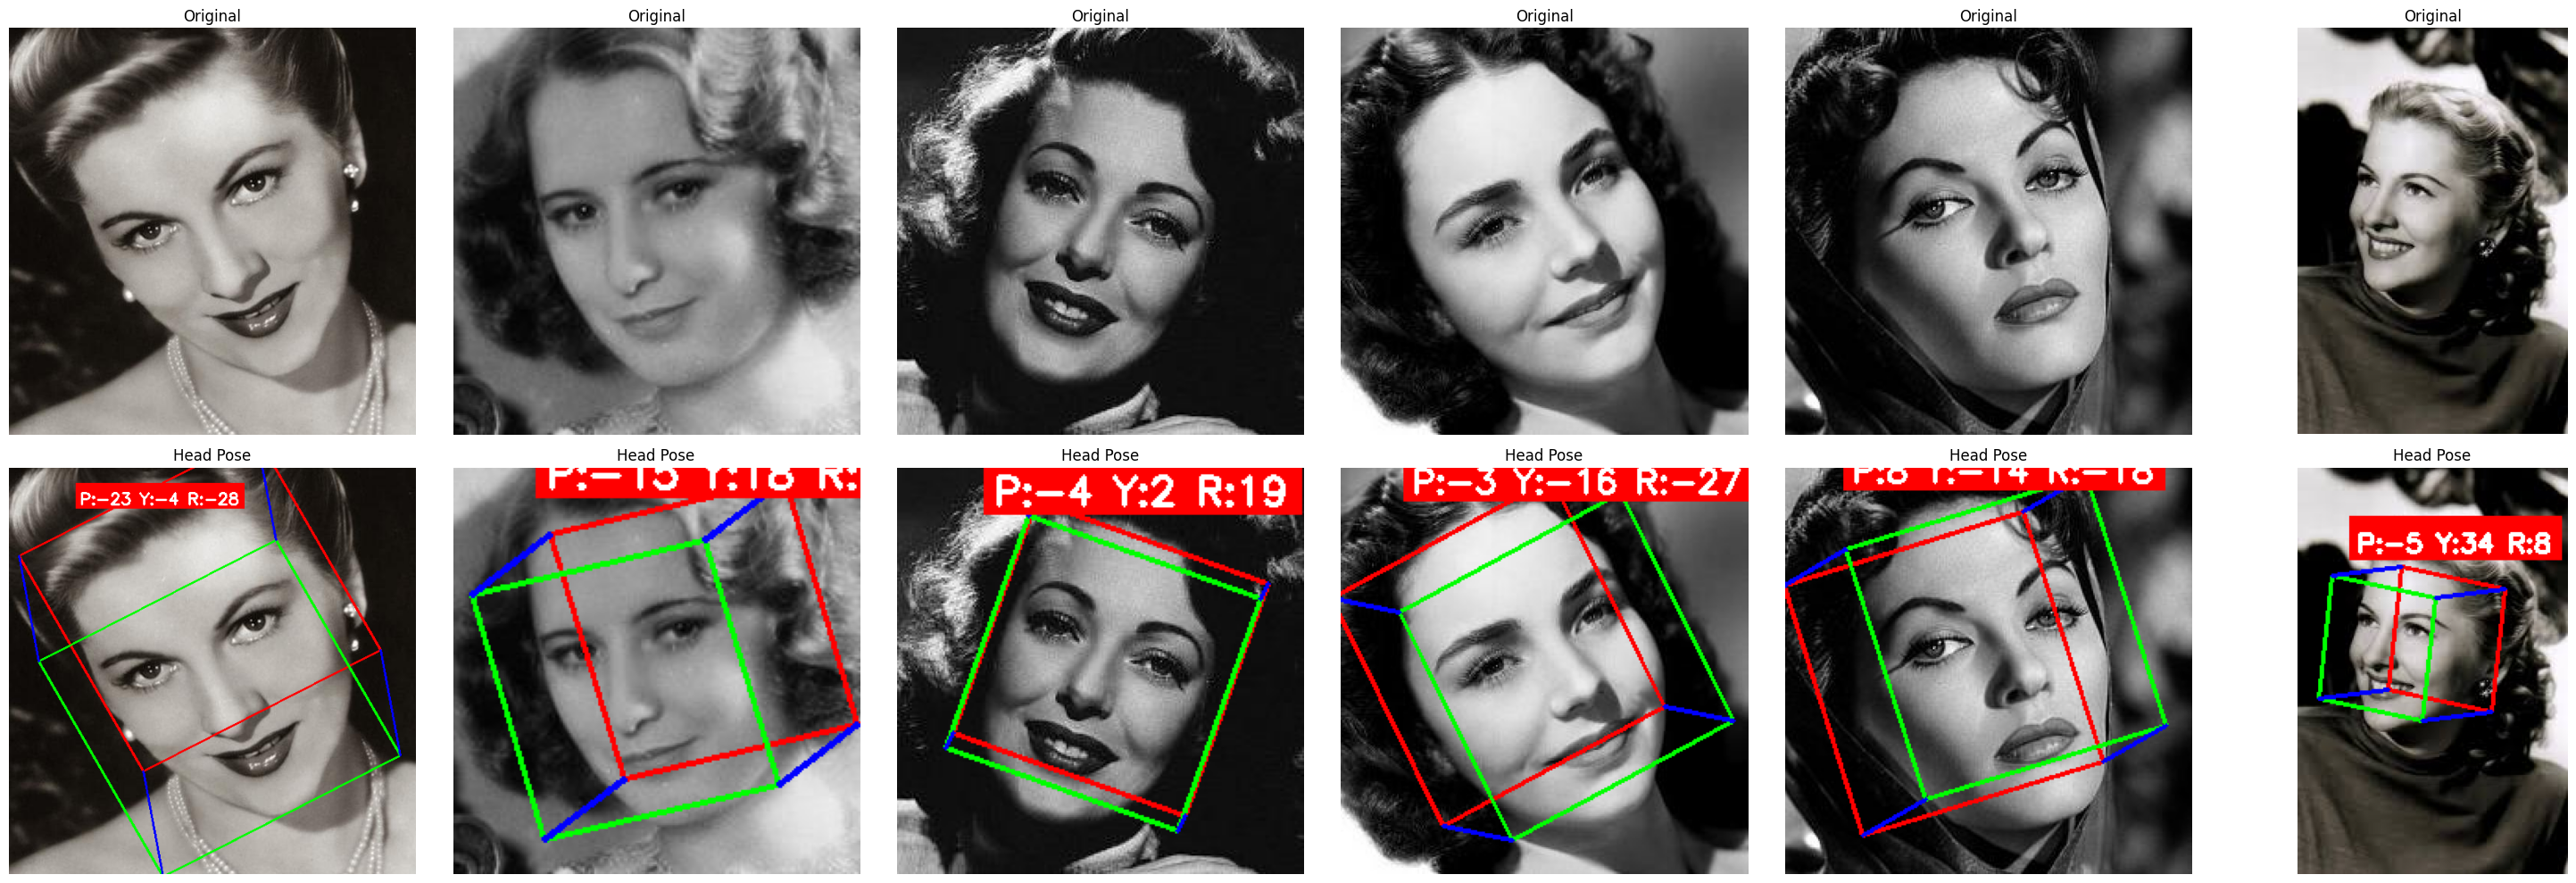

In [5]:
num_images = len(original_images)

# Create figure with 2 rows
fig, axes = plt.subplots(2, num_images, figsize=(5 * num_images, 10))

if num_images == 1:
    axes = axes.reshape(2, 1)

for i in range(num_images):
    axes[0, i].imshow(original_images[i])
    axes[0, i].set_title('Original', fontsize=12)
    axes[0, i].axis('off')

    axes[1, i].imshow(annotated_images[i])
    axes[1, i].set_title('Head Pose', fontsize=12)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

## Notes

- **Input**: Head pose estimation requires a face crop (obtained from face detection)
- **Output**: `HeadPoseResult` with pitch, yaw, and roll angles in **degrees**
- **Visualization**: Two modes available — `'cube'` (3D wireframe) and `'axis'` (X/Y/Z coordinate axes)
- **Models**: 6 backbone variants available via `HeadPoseWeights` enum
- **Method**: Uses 6D rotation representation converted to Euler angles

### Available Backbones

```python
from uniface.constants import HeadPoseWeights

# Options: RESNET18, RESNET34, RESNET50, MOBILENET_V2, MOBILENET_V3_SMALL, MOBILENET_V3_LARGE
head_pose = HeadPose(model_name=HeadPoseWeights.RESNET50)
```